In [1]:
from pathlib import Path
from typing import Union, Optional
import copy
import os

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.path import Path as mpPath
from matplotlib.collections import PathCollection
from matplotlib import axes
import xarray as xr
import pandas as pd
import geopandas as gpd
from spotpy.algorithms import _algorithm
import spotpy
import tqdm
from scipy.stats import wasserstein_distance
import dask.array as da

In [2]:
src_root = (Path('..') / 'src').resolve()
os.chdir(src_root)

from mihms.prep import prms as pprms
from mihms.models.models import PrmsModel
from mihms.output import PrmsOutput
from mihms.prep.utils import write_prms_datafile
from mihms.calibrate.algorithms import SensitivityAnalysis
from mihms.calibrate.obj_funcs import nse_md
from mihms.calibrate.database import MultiDimDb
from mihms.calibrate.utils import build_parameter_list

In [3]:
m_wd = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/streamflow_calibration')
prms_grid_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/prms/UY_prms_grid.shp')
gage_pourpnt_pth = Path('D:/ArcGIS_Projects/Yellowstone/Upper Yellowstone/Vector/prms_subbasin_pourpnts.shp')
obs_data_pth = Path('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/calibration_data/gage_observation_data.csv')

In [4]:
ppnts = gpd.read_file(gage_pourpnt_pth)
obsdat = pd.read_csv(obs_data_pth)
prmsgrid = gpd.read_file(prms_grid_pth)

In [40]:
prmscont = pprms.CreateControlFile(prms_exe=Path('C:/Users/CNB968/OneDrive - MT/Modeling/GSFLOW/PRMS/prms_6.0.0/bin/prms.exe'),
                               prms_version='6.0.0',
                               start_time='2018-01-01',
                               end_time='2024-12-31',
                               data_files=m_wd / 'UY_1979_2024.data',
                               param_files=m_wd / 'UY_params.param',
                               output_path=m_wd,
                               file_name='UY_streamflow.control')
prmscont.select_output_variables(['subinc_gwflow', 'sub_cfs', 'sub_inq', 'subinc_interflow', 'subinc_sroff', 'seg_inflow', 'seg_outflow', 'seg_lateral_inflow', 'strm_seg_in', ])

In [46]:
prmscont.control_obj.set_values('strmflow_module', ['muskingum_lake'])
prmscont.control_obj.set_values('cascadegw_flag', [2])

In [48]:
print(prmscont.control_obj.get_record('cascadegw_flag'))


####
cascadegw_flag
1
1
2
####


In [49]:
prmscont.save_controlfile()

In [5]:
prmscont = pprms.CreateControlFile.load_from_prms_controlfile(m_wd / 'UY_streamflow.control')

In [6]:
obds = pprms.domain.create_obs_dataset(obsdat, ppnts.iloc[:-1,:], 'station_id', prmsgrid)
lvout = ['06186500', '43B 05990', '43B 02990']
# Yel at Corwin & Yel at Carters
agg_sites = ['06191500', '06192500']
agg_segs = [522, 1086]
cal_locs = obds['location'][~np.isin(obds['location'].values, lvout)]
cal_obsdat = obds.sel(location=cal_locs)

In [7]:
mod = PrmsModel(prmscont)

------------------------------------
Reading parameter file : UY_params.param
------------------------------------


c:\Users\CNB968\.conda\envs\prms\lib\site-packages\gsflow\prms\prms_data.py:91: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_pd = pd.read_csv(fid, delim_whitespace=True, names=columns)


In [17]:
mod.control._out_pth

WindowsPath('D:/Modeling/GSFLOW/PRMS_Projects/Upper Yellowstone/streamflow_calibration/UY_nolake_segments_output')

In [60]:
mod.run_model(report=False)



                         U.S. Geological Survey
               Precipitation-Runoff Modeling System (PRMS)
                        Version 6.0.0 02/01/2025

--------------------------------------------------------------------
        Process            Available Modules
--------------------------------------------------------------------
  Basin Definition: basin
    Cascading Flow: cascade
  Time Series Data: obs, water_use_read, dynamic_param_read
                    dynamic_soil_param_read
   Potet Solar Rad: soltab
  Temperature Dist: temp_1sta, temp_laps, temp_dist2, climate_hru,
                    temp_map
       Precip Dist: precip_1sta, precip_laps, precip_dist2,
                    climate_hru, precip_map
Temp & Precip Dist: xyz_dist, ide_dist
    Solar Rad Dist: ccsolrad, ddsolrad, climate_hru
Transpiration Dist: transp_tindex, climate_hru, transp_frost
      Potential ET: potet_hamon, potet_jh, potet_pan, climate_hru,
                    potet_hs, potet_pt, potet_pm, pote

(True, [])

In [71]:
output = PrmsOutput(prmscont, obs_dset=obds)
segout = output.get_segment_output()
subout = output.get_subbasin_output()

In [72]:
output.observation_data

<xarray.Dataset>
Dimensions:           (time: 1827, location: 18)
Coordinates:
    lon               (location) float64 -110.4 -110.4 -110.7 ... -110.6 -110.8
    lat               (location) float64 44.58 44.93 44.99 ... 45.56 45.6 45.11
    hru               (location) int64 6784 38742 11433 ... 23540 18922 31608
  * location          (location) object '06186500' '06188000' ... '06191500'
  * time              (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
    subbasin          (location) int64 16 1 15 4 3 5 6 13 ... 9 2 12 11 10 18 17
    segment           (location) int64 400 162 137 1241 ... 954 1218 1086 522
Data variables:
    observation_data  (time, location) float64 374.0 155.0 110.0 ... 87.51 411.0
Attributes:
    description:  Observation data associated with PRMS model domain.

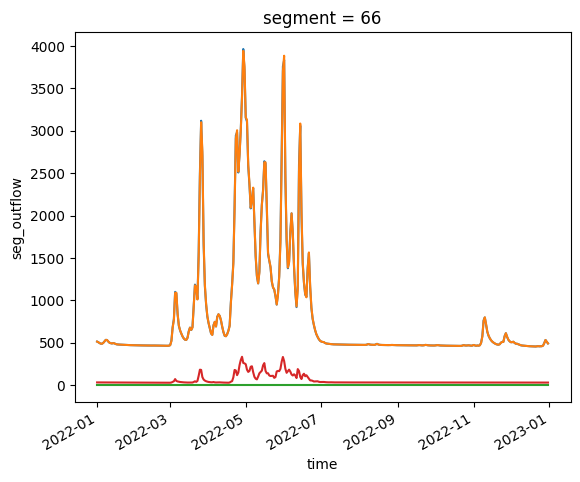

In [105]:
ax = plt.axes()
#subout.sub_cfs.sel(subbasin=1, time=slice('2022-01-01', '2022-12-31')).plot(ax=ax)
segout.seg_inflow.sel(segment=220, time=slice('2022-01-01', '2022-12-31')).plot(ax=ax)
segout.seg_outflow.sel(segment=220, time=slice('2022-01-01', '2022-12-31')).plot(ax=ax)
segout.seg_lateral_inflow.sel(segment=220, time=slice('2022-01-01', '2022-12-31')).plot(ax=ax)
segout.seg_outflow.sel(segment=66, time=slice('2022-01-01', '2022-12-31')).plot(ax=ax)

c:\Users\CNB968\.conda\envs\prms\lib\site-packages\xarray\core\dataset.py:6257: DeprecationWarning: `cumproduct` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `cumprod` instead.
  index = self.coords.to_index([*ordered_dims])


<Axes: xlabel='time'>

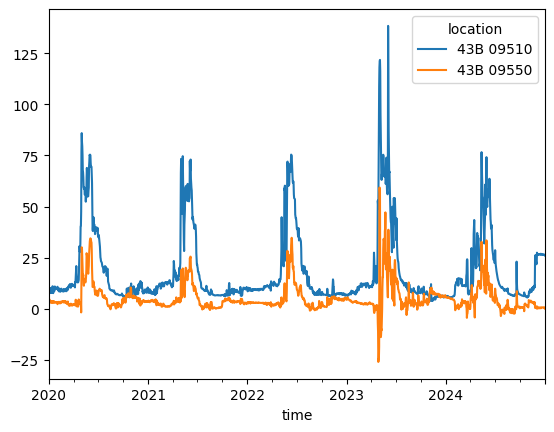

In [23]:
trlcrk = output.observation_data.observation_data.sel(location=['43B 09510', '43B 09550']).to_dataframe()
pd.pivot_table(trlcrk['observation_data'].reset_index(), 'observation_data', 'time', 'location').plot()

In [107]:
output.observation_data

<xarray.Dataset>
Dimensions:           (time: 1827, location: 18)
Coordinates:
    lon               (location) float64 -110.4 -110.4 -110.7 ... -110.6 -110.8
    lat               (location) float64 44.58 44.93 44.99 ... 45.56 45.6 45.11
    hru               (location) int64 6784 38742 11433 ... 23540 18922 31608
  * location          (location) object '06186500' '06188000' ... '06191500'
  * time              (time) datetime64[ns] 2020-01-01 2020-01-02 ... 2024-12-31
    subbasin          (location) int64 16 1 15 4 3 5 6 13 ... 9 2 12 11 10 18 17
    segment           (location) int64 400 162 137 1241 ... 954 1218 1086 522
Data variables:
    observation_data  (time, location) float64 374.0 155.0 110.0 ... 87.51 411.0
Attributes:
    description:  Observation data associated with PRMS model domain.

In [108]:
yel_blw_lk = segout.seg_outflow.sel(segment=522, time=slice('2020-01-01', '2024-12-31')) - (segout.seg_outflow.sel(segment=400, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=1241, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=162, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=137, time=slice('2020-01-01', '2024-12-31'))
                                                                                            )
yel_crwn_cart = segout.seg_outflow.sel(segment=1086, time=slice('2020-01-01', '2024-12-31')) - (segout.seg_inflow.sel(segment=522, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=954, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=644, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=1084, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=617, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=480, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=733, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=1124, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                segout.seg_outflow.sel(segment=1204, time=slice('2020-01-01', '2024-12-31'))
                                                                                                )

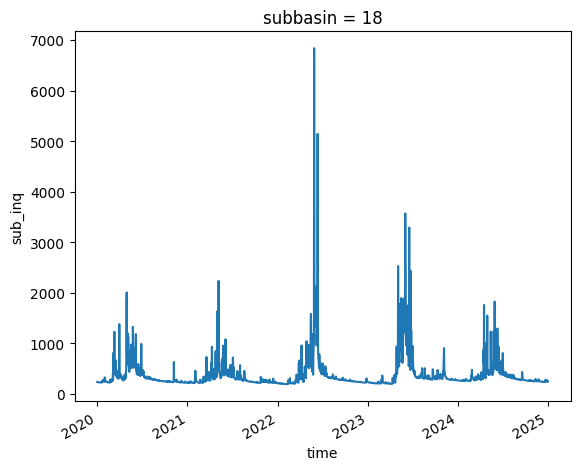

In [115]:
ax = plt.axes()
subout.sub_inq.sel(subbasin=18, time=slice('2020-01-01', '2024-12-31')).plot()

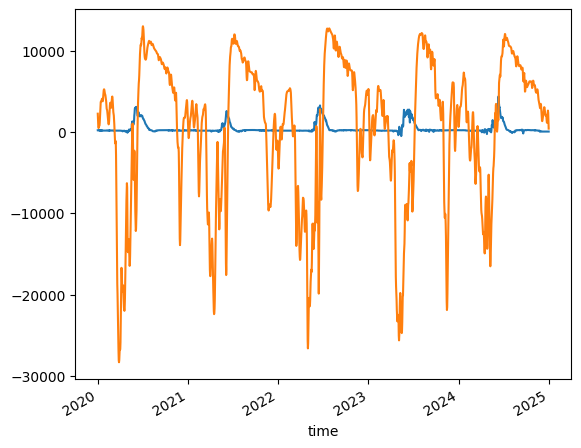

In [109]:
ax = plt.axes()
output.observation_data.observation_data.sel(location='06192500').plot(ax=ax)
yel_crwn_cart.plot(ax=ax)

In [ ]:
segout.seg_outflow.sel(segment=output.observation_data)

<xarray.Dataset>
Dimensions:              (time: 2557, segment: 1352)
Coordinates:
  * segment              (segment) int32 1 2 3 4 5 ... 1348 1349 1350 1351 1352
  * time                 (time) datetime64[ns] 2018-01-01 ... 2024-12-31
Data variables:
    seg_inflow           (time, segment) float64 1.237e+06 6.407e+04 ... 350.8
    seg_outflow          (time, segment) float64 1.237e+06 6.407e+04 ... 350.8
    strm_seg_in          (time, segment) float64 3.688e+03 86.02 ... 0.0028 0.0
    seg_upstream_inflow  (time, segment) float64 1.234e+06 6.399e+04 ... 350.8

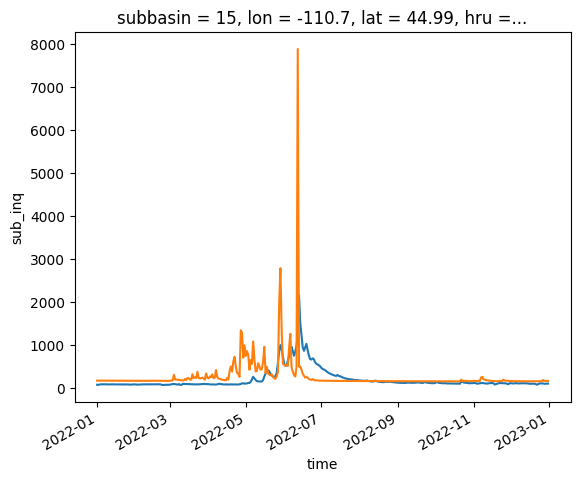

In [122]:
gage_id = '06191000'
timeslc = slice('2022-01-01', '2022-12-31')
seg = output.observation_data['segment'].sel(location=gage_id)
sub = output.observation_data['subbasin'].sel(location=gage_id)
ax = plt.axes()
output.observation_data.observation_data.sel(location=gage_id, time=timeslc).plot(ax=ax)
subout.sub_inq.sel(subbasin=sub, time=timeslc).plot(ax=ax)
#segout['seg_inflow'].sel(segment=seg, time=timeslc).plot(ax=ax)

In [91]:
mod.parameters.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 45244, nsub: 19, nsegment: 1352,
                           ncascade: 88141, nlake: 1, nmonths: 12, ntemp: 104,
                           nssr: 45244, ngw: 45244, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nlake,
                                nmonths, ntemp, nssr, ngw, ndeplval
Data variables: (12/117)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 17 16 1 17 1 15
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 45.11 45.11 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.2 -110.8
    lake_hru_id           (nhru) int32 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    ...                    ...
    ppt_rad_adj           (nmonths, nhru) float64 0.02 0.02 0.02 ... 0.02 0.02
    radj_sppt             (nhru) float64 0.44 0.44 0.44 0.44 ... 0.44 0.44 0.44
    radj_wppt             (nhru) float64 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    radmax                (nmonths, nhru) float64 0.8 0.8 0.8 ... 0.8 0.8 0.8
    tmax_index            (nmonths, nhru) float64 50.0 50.0 50.0 ... 50.0 50.0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [38]:
loc.values

array(644)

In [19]:
grd_vertices = prmsgrid.geometry.get_coordinates()
gbnds = prmsgrid.total_bounds
mp_pths = []
for i in prmsgrid.index:
    npth = mpPath(grd_vertices.loc[i,:].values)
    mp_pths.append(npth)

In [8]:
p = mod.parameters

In [9]:
p.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nssr: 46199, ngw: 46199, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw, ndeplval
Data variables: (12/108)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    melt_look             (nhru) int32 90 90 90 90 90 90 ... 90 90 90 90 90 90
    settle_const          (nhru) float64 0.1 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    snarea_thresh         (nhru) float64 50.0 50.0 50.0 50.0 ... 50.0 50.0 50.0
    cecn_coef             (nmonths, nhru) float64 5.0 5.0 5.0 ... 5.0 5.0 5.0
    tstorm_mo             (nmonths, nhru) int32 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [10]:
potet_attrs = p.parameters['potet_sublim'].attrs
p.parameters['potet_sublim'] = xr.DataArray(np.repeat(0.5, p.parameters.sizes['nhru']), dims=['nhru'], attrs=potet_attrs)

In [11]:
p.write_paramfile()

In [31]:
p.change_parameter_by_subbasin('adjmix_rain', np.array([1.4, 1.5, 1.2, 1.1, 1.1, 1.6, 1.3, 1.0, 1.5, 1.1, 1.2, 1.3, 1.5, 1.3, 1.4]), cal_obsdat.subbasin.values)

In [33]:
p.write_paramfile()

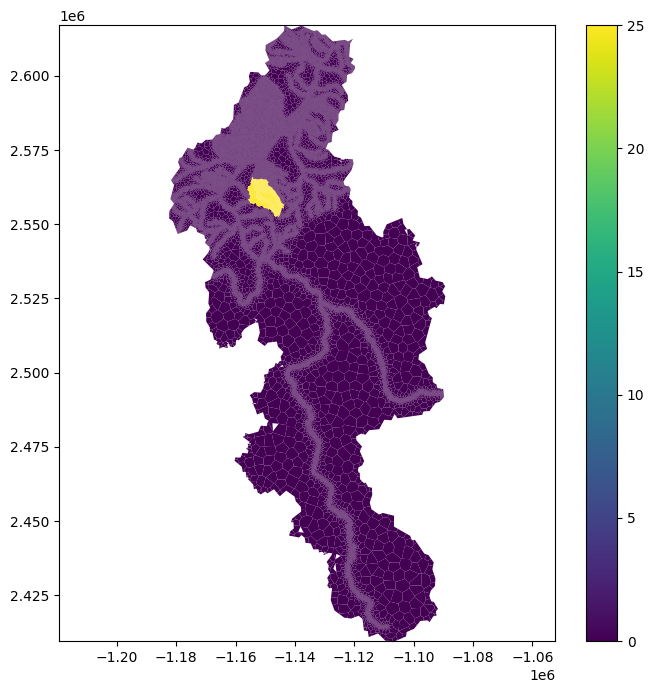

In [17]:
inarr = p.parameters['tmax_allsnow'].values[0,:]

kwargs = {}
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
collection = PathCollection(mp_pths)
collection.set_array(inarr)
vmin = kwargs.pop("vmin", None)
vmax = kwargs.pop("vmax", None)
kwargs["cmap"] = "viridis"
collection.set_clim(vmin=vmin, vmax=vmax)
collection.set(**kwargs)
ax.add_collection(collection)
ax.set_xlim(gbnds[0], gbnds[2])
ax.set_ylim(gbnds[1], gbnds[3])
fig.colorbar(collection, ax=ax)

In [8]:
class MscuaSetupSA:
    # Define parameters here (before __init__) as variables
    # These are the parameters specific to your model and will need to be defined for each MscuaSetup class
    adjmix_rain = spotpy.parameter.Uniform(low=0.0, high=3.0)
    tmax_allsnow = spotpy.parameter.Uniform(low=-10.0, high=40.0)
    tmax_allrain_offset = spotpy.parameter.Uniform(low=0.0, high=50.0)
    imperv_stor_max = spotpy.parameter.Uniform(low=0.0, high=0.5)
    potet_sublim = spotpy.parameter.Uniform(low=0.00001, high=0.75)
    sat_threshold = spotpy.parameter.Uniform(low=0.0, high=999.0)
    smidx_coef = spotpy.parameter.Uniform(low=0.0, high=1.0)
    smidx_exp = spotpy.parameter.Uniform(low=0.0, high=5.0)
    fastcoef_lin = spotpy.parameter.Uniform(low=0.0, high=1.5)
    fastcoef_sq = spotpy.parameter.Uniform(low=0.0, high=1.0)
    slowcoef_lin = spotpy.parameter.Uniform(low=0.0, high=1.0)
    slowcoef_sq = spotpy.parameter.Uniform(low=0.0, high=1.0)
    pref_flow_den = spotpy.parameter.Uniform(low=0.0, high=0.5)
    pref_flow_infil_frac = spotpy.parameter.Uniform(low=-1.0, high=1.0)
    soil_rechr_max_frac = spotpy.parameter.Uniform(low=0.00001, high=1.0)
    soil2gw_max = spotpy.parameter.Uniform(low=0.0, high=5.0)
    ssr2gw_exp = spotpy.parameter.Uniform(low=0.0, high=3.0)
    ssr2gw_rate = spotpy.parameter.Uniform(low=0.00001, high=1.0)
    gwflow_coef = spotpy.parameter.Uniform(low=0.0, high=5.0)
    gwsink_coef = spotpy.parameter.Uniform(low=0.0, high=1.0)
    gwstor_min = spotpy.parameter.Uniform(low=0.0, high=1.0)
    freeh2o_cap = spotpy.parameter.Uniform(low=0.01, high=0.2)
    settle_const = spotpy.parameter.Uniform(low=0.01, high=0.5)
    snarea_thresh = spotpy.parameter.Uniform(low=0.0, high=200.0)

    def __init__(self, objective_funcs, dbase: Optional[Union[str, Path, MultiDimDb]] = None):
        # define the multidimensional parameter space here
        self.parameter_dimension = 15
        self.param_dim_name = 'subbasin'
        
        self.model = mod
        self.observation_data = cal_obsdat
        self.param_archive = copy.deepcopy(self.model.parameters.parameters)
        self.calperiod = slice(self.observation_data.time.values[0], self.observation_data.time.values[-1])
        if isinstance(objective_funcs, list):
            self.objfuncs = objective_funcs
        else:
            self.objfuncs = [objective_funcs]
    
    def parameters(self):
        plist = build_parameter_list(self, self.parameter_dimension, self.param_dim_name)
        init_samp = {}
        for p in plist:
            name = p.name
            sv = np.repeat(p(), p.dim)
            init_samp.update({name: sv})
        
        return init_samp
    
    def simulation(self, paramdict: Optional[dict] = None, rslt_type: str = 'sub', verbose: bool = False):
        if paramdict is None:
            if verbose:
                print("No New Parameters to assign...running model with existing parameters")
            self.model.run_model(silent=True, report=False)
            if verbose:
                print("finished model run")
        else:
            for k,v in paramdict.items():
                self.model.parameters.change_parameter_by_subbasin(k, v, self.observation_data['subbasin'].values)
            
            if verbose:
                print("writing new paramfile")
            self.model.parameters.write_paramfile()
            self.model.run_model(silent=True, report=False)
            if verbose:
                print("finished model run")
        res = PrmsOutput(self.model.control)
        segout = res.get_segment_output()
        subout = res.get_subbasin_output()

        yel_blw_lk = segout.seg_outflow.sel(segment=522, time=slice('2020-01-01', '2024-12-31')) - (segout.seg_outflow.sel(segment=400, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=1241, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=162, time=slice('2020-01-01', '2024-12-31')) + 
                                                                                            segout.seg_outflow.sel(segment=137, time=slice('2020-01-01', '2024-12-31'))
                                                                                            )
        yel_crwn_cart = segout.seg_outflow.sel(segment=1086, time=slice('2020-01-01', '2024-12-31')) - (segout.seg_inflow.sel(segment=522, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=954, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=644, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=1084, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=617, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=480, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=733, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=1124, time=slice('2020-01-01', '2024-12-31')) +
                                                                                                        segout.seg_outflow.sel(segment=1204, time=slice('2020-01-01', '2024-12-31'))
                                                                                                        )
        if verbose:
            print("Formatting model simulation results...")
        if rslt_type == 'seg':
            sim_arr = np.empty(self.observation_data.observation_data.values.shape)
            for i, s in enumerate(self.observation_data.segment.values):
                if s == 522:
                    simvals = yel_blw_lk
                elif s == 1086:
                    simvals = yel_crwn_cart
                else:
                    simvals = segout.seg_outflow.sel(segment=s, time=self.calperiod).values
                sim_arr[:,i] = simvals
        elif rslt_type == 'sub':
            sim_arr = np.empty(self.observation_data.observation_data.values.shape)
            for i, s in enumerate(self.observation_data.subbasin.values):
                simvals = subout.sub_inq.sel(subbasin=s, time=self.calperiod).values
                sim_arr[:,i] = simvals
        else:
            raise ValueError(f"Result Type: {rslt_type} not recognized, use 'sub' or 'seg'")
        
        if verbose:
            print("Resetting original parameters...")
        self.model.parameters.parameters = self.param_archive
        self.model.parameters.write_paramfile()

        return sim_arr
    
    def evaluation(self):
        return self.observation_data.observation_data.values

    def objectivefunction(self, observation, simulation):
        results = {}
        for o in tqdm.tqdm(self.objfuncs, desc="Calculating Objective Functions", leave=False):
            r = o(observation=observation, simulation=simulation, return_dict=True)
            results.update(r)
        
        return results

In [9]:
setup = MscuaSetupSA(nse_md)

## Play Around with the Setup Class - You can use this to run the model and assess the results of individual runs.

Here's just a single run of the model with the existing parameters (if no new parameter set is passed to the ```.simulation()``` method, it will run with the saved parameter file as is).

In [10]:
rsult = setup.simulation(verbose=True)

No New Parameters to assign...running model with existing parameters
finished model run
Formatting model simulation results...
Resetting original parameters...


This returns a 2D array where each column is the output time-series of a sub-basin. The order is from the ```setup.observation_data``` dataset.

In [11]:
rsult

array([[465.6167, 155.3984,  26.5622, ...,  27.4092, 237.2689, 444.0664],
       [465.1487, 155.3474,  26.4782, ...,  27.3409, 233.7118, 440.82  ],
       [466.3337, 155.3213,  26.4576, ...,  27.0941, 233.5272, 441.2761],
       ...,
       [787.9109, 206.7145,  29.6971, ...,  30.9993, 263.6983, 726.8653],
       [633.4833, 190.0787,  28.3664, ...,  28.6544, 248.0073, 561.3872],
       [622.4424, 188.881 ,  27.8352, ...,  27.9251, 244.4302, 563.483 ]])

We can calculate the NSE (objective function used to initialize the setup class in this instance) for this single model run using the ```setup.objectivefunction()```

In [13]:
obfn = setup.objectivefunction(setup.evaluation(), rsult)

In [14]:
obfn

{'nse': array([-2.12295836e-02, -1.26693177e+00,  2.22954684e-01, -1.11846864e+01,
        -7.79189742e+00, -1.05541772e+00, -1.19351025e+01, -2.64863350e+00,
        -1.40778082e+00,  1.05249103e-01,  2.90059670e-01, -4.15717555e+01,
        -2.43252740e+00,  1.26140015e-01, -1.03890070e+00])}

Since in this case PRMS writes results to file, we can also use the ```PrmsOutput``` class to access all our results outside of the setup class for more diagnostics/visualization.

In [15]:
output = PrmsOutput(setup.model.control)
segout = output.get_segment_output()
subout = output.get_subbasin_output()

Visualize segment results, in this case, compare 2 segments.

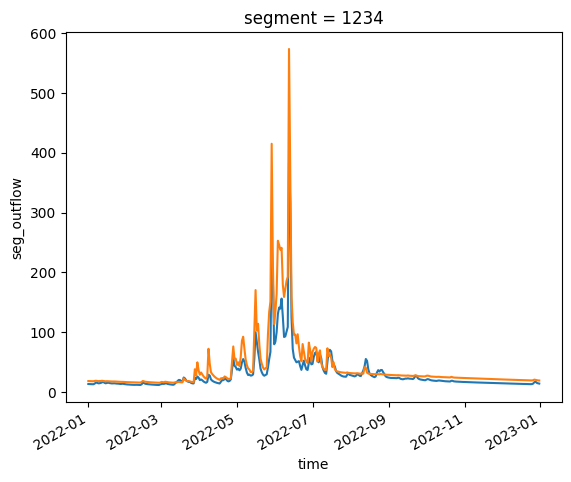

In [27]:
seg_id = 1014
seg_id2 = 1234
timeslc = slice('2022-01-01', '2022-12-31')
out_var = 'seg_outflow'
ax = plt.axes()
segout[out_var].sel(segment=seg_id, time=timeslc).plot(ax=ax)
segout[out_var].sel(segment=seg_id2, time=timeslc).plot(ax=ax)

In [ ]:
gage_id = '06191000'
timeslc = slice('2022-01-01', '2022-12-31')
seg = output.observation_data['segment'].sel(location=gage_id)
sub = output.observation_data['subbasin'].sel(location=gage_id)
ax = plt.axes()
output.observation_data.observation_data.sel(location=gage_id, time=timeslc).plot(ax=ax)
subout.sub_inq.sel(subbasin=sub, time=timeslc).plot(ax=ax)
#segout['seg_inflow'].sel(segment=seg, time=timeslc).plot(ax=ax)

## Run a Sensitivity Analysis using the ```SensitivityAnalysis()``` class.

In [10]:
sampler = SensitivityAnalysis(setup)

Get Default Parameter Dictionary

In [11]:
default_params = setup.parameters()
for k,v in default_params.items():
    d = float(setup.model.parameters.parameters[k].attrs['default'])
    default_params[k] = d

In [12]:
default_params

{'adjmix_rain': 1.0,
 'tmax_allsnow': 32.0,
 'tmax_allrain_offset': 1.0,
 'imperv_stor_max': 0.05,
 'potet_sublim': 0.5,
 'sat_threshold': 999.0,
 'smidx_coef': 0.005,
 'smidx_exp': 0.3,
 'fastcoef_lin': 0.1,
 'fastcoef_sq': 0.8,
 'slowcoef_lin': 0.015,
 'slowcoef_sq': 0.1,
 'pref_flow_den': 0.0,
 'pref_flow_infil_frac': -1.0,
 'soil_rechr_max_frac': 1.0,
 'soil2gw_max': 0.0,
 'ssr2gw_exp': 1.0,
 'ssr2gw_rate': 0.1,
 'gwflow_coef': 0.015,
 'gwsink_coef': 0.0,
 'gwstor_min': 0.0,
 'freeh2o_cap': 0.05,
 'settle_const': 0.1,
 'snarea_thresh': 50.0}

In [13]:
sampler.sample(defaults=default_params)

Sampling 10 repetitions of the adjmix_rain parameter...


Sampling 10 repetitions of the tmax_allsnow parameter...


Sampling 10 repetitions of the tmax_allrain_offset parameter...


Sampling 10 repetitions of the imperv_stor_max parameter...


Sampling 10 repetitions of the potet_sublim parameter...


...

Sampling 10 repetitions of the gwsink_coef parameter...


Sampling 10 repetitions of the gwstor_min parameter...


Sampling 10 repetitions of the freeh2o_cap parameter...


Sampling 10 repetitions of the settle_const parameter...


Sampling 10 repetitions of the snarea_thresh parameter...


In [15]:
sampler.results.to_netcdf(m_wd / "UY_nolake_segments_sensitivity_analysis.nc")

In [27]:
sampler.results.parameters

<xarray.DataArray 'parameters' (parameters: 24)>
array(['adjmix_rain', 'tmax_allsnow', 'tmax_allrain_offset', 'imperv_stor_max',
       'potet_sublim', 'sat_threshold', 'smidx_coef', 'smidx_exp',
       'fastcoef_lin', 'fastcoef_sq', 'slowcoef_lin', 'slowcoef_sq',
       'pref_flow_den', 'pref_flow_infil_frac', 'soil_rechr_max_frac',
       'soil2gw_max', 'ssr2gw_exp', 'ssr2gw_rate', 'gwflow_coef',
       'gwsink_coef', 'gwstor_min', 'freeh2o_cap', 'settle_const',
       'snarea_thresh'], dtype='<U20')
Coordinates:
  * parameters  (parameters) <U20 'adjmix_rain' ... 'snarea_thresh'

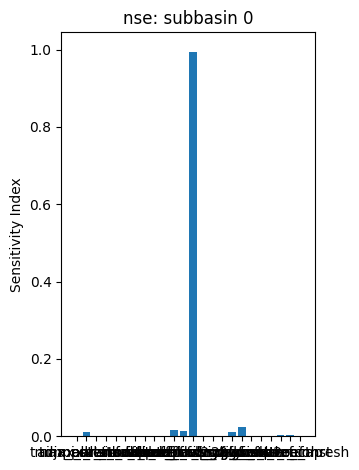

In [53]:
sampler.plot_sensitivity_index(0)

In [10]:
sa_file = xr.open_dataset(m_wd / 'UY_nolake_segments_sensitivity_analysis.nc')
fl_SA = SensitivityAnalysis(setup, results_ds=sa_file)

In [55]:
msk = np.where(fl_SA.results.samples.sel(parameters='pref_flow_den').values > 1)

In [57]:
fl_SA.results['nse'].sel(parameters='pref_flow_den').values[msk] = np.nan

In [61]:
fl_SA.results

<xarray.Dataset>
Dimensions:              (parameters: 24, repetitions: 10, subbasin: 15,
                          objective_functions: 1)
Coordinates:
  * parameters           (parameters) object 'adjmix_rain' ... 'snarea_thresh'
  * repetitions          (repetitions) int32 1 2 3 4 5 6 7 8 9 10
  * subbasin             (subbasin) int32 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15
  * objective_functions  (objective_functions) object 'nse'
Data variables:
    samples              (parameters, repetitions, subbasin) float64 ...
    nse                  (parameters, repetitions, subbasin) float64 0.008589...
    sensitivity_index    (objective_functions, parameters, subbasin) float64 ...

In [65]:
sens_indx = da.from_array(np.empty((len(fl_SA.results['objective_functions'].values), len(fl_SA.results['parameters'].values), len(fl_SA.results['subbasin'].values))),
                                  chunks='auto')
for i, obf in enumerate(fl_SA.results['objective_functions'].values.tolist()):
    d = np.nanmax(fl_SA.results[obf].values, axis=(0, 1)) - np.nanmin(fl_SA.results[obf].values, axis=(0, 1))
    for j, par in enumerate(fl_SA.results['parameters'].values.tolist()):
        n = np.nanmax(fl_SA.results[obf].sel(parameters=par).values, axis=0) - np.nanmin(
            fl_SA.results[obf].sel(parameters=par).values, axis=0)
        sens_arr = n / d
        sens_indx[i, j, :] = sens_arr
fl_SA.results['sensitivity_index'] = (('objective_functions', 'parameters', 'subbasin'), sens_indx)

sub-basin: 17
gage ID: 06191500


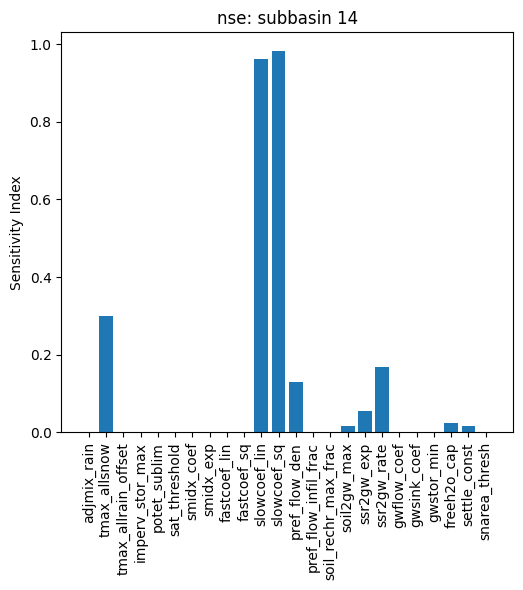

In [95]:

indx = 14
print(f"sub-basin: {cal_obsdat.subbasin.values[indx]}")
print(f"gage ID: {cal_obsdat.location.values[indx]}")

axwidth = 2
n = len(fl_SA.results.objective_functions)
if n % axwidth == 0:
    fig, axs = plt.subplots(int(n / axwidth), axwidth, figsize=(10, 6))
else:
    fig, axs = plt.subplots(int(n / axwidth + 1), axwidth, figsize=(10, 6))
if len(axs.shape) > 1:
    for i, v in enumerate(fl_SA.results.objective_functions.values.tolist()):
        ax_i = axs[int(i / axwidth), i % axwidth]
        ax_i.bar(fl_SA.results['parameters'].values,
                    fl_SA.results['sensitivity_index'].sel(objective_functions=v).values[:, indx])
        ax_i.set_title(f"{v}: {fl_SA.results['sensitivity_index'].dims[2]} {indx}")
        ax_i.tick_params(axis='x', labelrotation=90)
else:
    for i, v in enumerate(fl_SA.results.objective_functions.values.tolist()):
        ax_i = axs[i % axwidth]
        ax_i.bar(fl_SA.results['parameters'].values,
                    fl_SA.results['sensitivity_index'].sel(objective_functions=v).values[:, indx])
        ax_i.set_title(f"{v}: {fl_SA.results['sensitivity_index'].dims[2]} {indx}")
        ax_i.tick_params(axis='x', labelrotation=90)
if n % axwidth != 0:
    if len(axs.shape) > 1:
        for l in axs[int(n / axwidth) - 1, n % axwidth].get_xaxis().get_majorticklabels():
            l.set_visible(True)
        fig.delaxes(axs[int(n / axwidth), n % axwidth])
        for ax in axs[:, 0]:
            ax.set_ylabel("Sensitivity Index")
    else:
        for l in axs[n % axwidth].get_xaxis().get_majorticklabels():
            l.set_visible(True)
        fig.delaxes(axs[n % axwidth])
        axs[0].set_ylabel("Sensitivity Index")
plt.tight_layout()
plt.show()

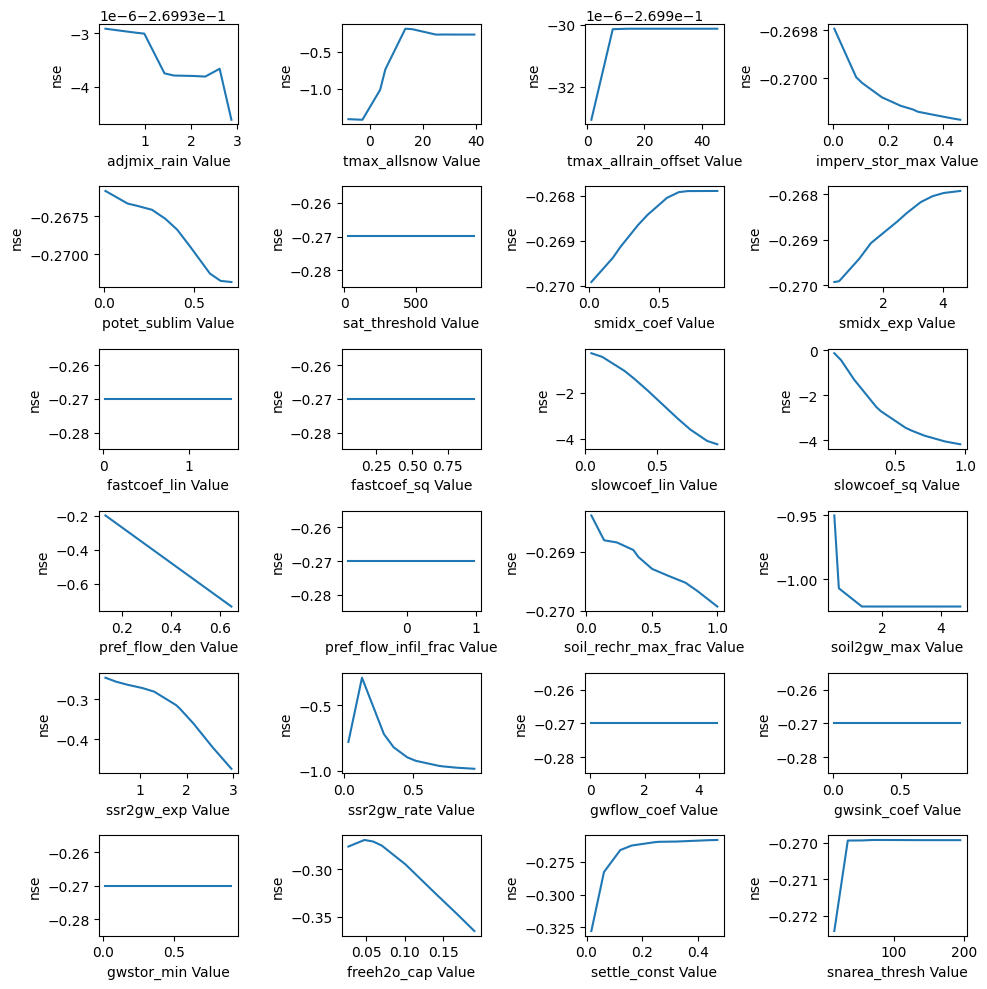

In [96]:
obj_func = 'nse'
axwidth = 4
n = len(fl_SA.results.parameters)
if n % axwidth == 0:
    fig, axs = plt.subplots(int(n / axwidth), axwidth, figsize=(10, 10))
else:
    fig, axs = plt.subplots(int(n / axwidth + 1), axwidth, figsize=(10, 10))
for i, v in enumerate(fl_SA.results.parameters.values.tolist()):
    ax_i = axs[int(i / axwidth), i % axwidth]
    ax_i.plot(fl_SA.results['samples'].sel(parameters=v).values[:, indx],
                fl_SA.results[obj_func].sel(parameters=v).values[:, indx])
    ax_i.set_xlabel(f"{v} Value")
    ax_i.set_ylabel(obj_func)
if n % axwidth != 0:
    if len(axs.shape) > 1:
        for l in axs[int(n / axwidth) - 1, n % axwidth].get_xaxis().get_majorticklabels():
            l.set_visible(True)
        fig.delaxes(axs[int(n / axwidth), n % axwidth])
    else:
        for l in axs[n % axwidth].get_xaxis().get_majorticklabels():
            l.set_visible(True)
        fig.delaxes(axs[n % axwidth])
plt.tight_layout()
plt.show()

In [104]:
setup.param_archive

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 46199, nsub: 19, nsegment: 1352,
                           ncascade: 90541, nmonths: 12, ntemp: 104,
                           nssr: 46199, ngw: 46199, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nmonths,
                                ntemp, nssr, ngw, ndeplval
Data variables: (12/108)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 2 17 2 17 17 16
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 44.43 44.14 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.0 -110.8
    hru_elev              (nhru) float64 1.794e+03 1.711e+03 ... 2.319e+03
    ...                    ...
    melt_look             (nhru) int32 90 90 90 90 90 90 ... 90 90 90 90 90 90
    settle_const          (nhru) float64 0.1 0.1 0.1 0.1 0.1 ... 0.1 0.1 0.1 0.1
    snarea_thresh         (nhru) float64 50.0 50.0 50.0 ... 194.6 194.6 194.6
    cecn_coef             (nmonths, nhru) float64 5.0 5.0 5.0 ... 5.0 5.0 5.0
    tstorm_mo             (nmonths, nhru) int32 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

In [107]:
print(mod.control.control_obj.get_record('nsegmentOutVar_names'))


####
nsegmentOutVar_names
4
4
seg_inflow
seg_outflow
strm_seg_in
seg_upstream_inflow
####


In [87]:
fl_SA.results.samples.sel(parameters='soil2gw_max').values

array([[0.35861659, 0.35861659, 0.35861659, 0.35861659, 0.35861659,
        0.35861659, 0.35861659, 0.35861659, 0.35861659, 0.35861659,
        0.35861659, 0.35861659, 0.35861659, 0.35861659, 0.35861659],
       [0.51418633, 0.51418633, 0.51418633, 0.51418633, 0.51418633,
        0.51418633, 0.51418633, 0.51418633, 0.51418633, 0.51418633,
        0.51418633, 0.51418633, 0.51418633, 0.51418633, 0.51418633],
       [1.30127753, 1.30127753, 1.30127753, 1.30127753, 1.30127753,
        1.30127753, 1.30127753, 1.30127753, 1.30127753, 1.30127753,
        1.30127753, 1.30127753, 1.30127753, 1.30127753, 1.30127753],
       [1.81513155, 1.81513155, 1.81513155, 1.81513155, 1.81513155,
        1.81513155, 1.81513155, 1.81513155, 1.81513155, 1.81513155,
        1.81513155, 1.81513155, 1.81513155, 1.81513155, 1.81513155],
       [2.05095107, 2.05095107, 2.05095107, 2.05095107, 2.05095107,
        2.05095107, 2.05095107, 2.05095107, 2.05095107, 2.05095107,
        2.05095107, 2.05095107, 2.05095107, 

- adjmix_rain = 
- tmax_allsnow = 7
- tmax_allrain_offset = 
- imperv_stor_max
- potet_sublim =
- sat_threshold = 
- smidx_coef = 
- smidx_exp =
- fastcoef_lin =
- fastcoef_sq = 
- slowcoef_lin = 7
- slowcoef_sq = 7
- pref_flow_den = 6
- pref_flow_infil_frac = 
- soil_rechr_max =
- soil2gw_max = 4
- ssr2gw_exp = 6
- ssr2gw_rate = 7
- gwflow_coef =
- gwsink_coef =
- gwstor_min =
- freeh2o_cap = 7
- settle_const = 4
- snarea_thresh =

Get Grid Collection for plotting arrays on PRMS grid.

In [31]:
grd_vertices = prmsgrid.geometry.get_coordinates()
gbnds = prmsgrid.total_bounds
mp_pths = []
for i in prmsgrid.index:
    npth = mpPath(grd_vertices.loc[i,:].values)
    mp_pths.append(npth)

In [28]:
mod.parameters.parameters

<xarray.Dataset>
Dimensions:               (one: 1, nhru: 45244, nsub: 19, nsegment: 1352,
                           ncascade: 88141, nlake: 1, nmonths: 12, ntemp: 104,
                           nssr: 45244, ngw: 45244, ndeplval: 11)
Dimensions without coordinates: one, nhru, nsub, nsegment, ncascade, nlake,
                                nmonths, ntemp, nssr, ngw, ndeplval
Data variables: (12/117)
    elev_units            (one) int32 1
    hru_type              (nhru) int32 1 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1 1
    hru_subbasin          (nhru) int32 19 19 19 19 19 19 19 ... 17 16 1 17 1 15
    hru_lat               (nhru) float64 45.75 45.74 45.74 ... 45.11 45.11 44.81
    hru_lon               (nhru) float64 -110.7 -110.6 -110.6 ... -110.2 -110.8
    lake_hru_id           (nhru) int32 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    ...                    ...
    ppt_rad_adj           (nmonths, nhru) float64 0.02 0.02 0.02 ... 0.02 0.02
    radj_sppt             (nhru) float64 0.44 0.44 0.44 0.44 ... 0.44 0.44 0.44
    radj_wppt             (nhru) float64 0.5 0.5 0.5 0.5 0.5 ... 0.5 0.5 0.5 0.5
    radmax                (nmonths, nhru) float64 0.8 0.8 0.8 ... 0.8 0.8 0.8
    tmax_index            (nmonths, nhru) float64 50.0 50.0 50.0 ... 50.0 50.0
    jh_coef               (nmonths, nhru) float64 0.014 0.014 ... 0.014 0.014

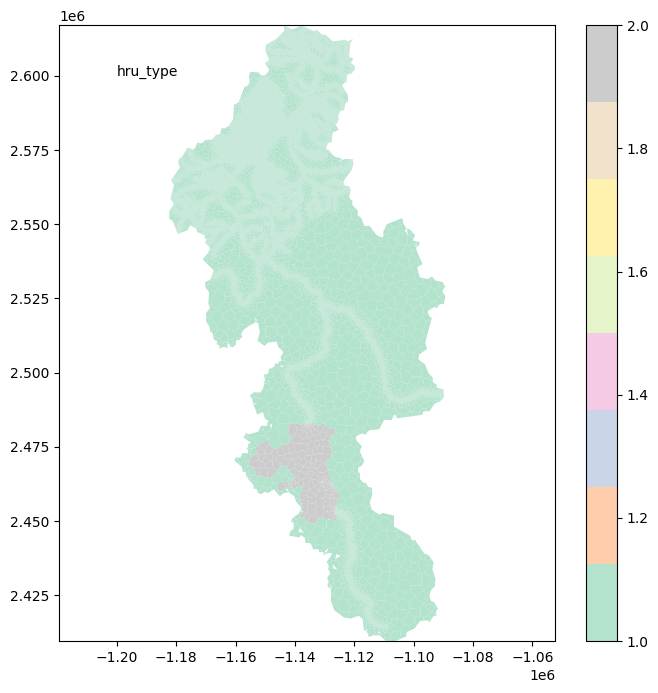

In [59]:
param = 'hru_type'
inarr = mod.parameters.parameters[param].values
cramp = 'Pastel2'

kwargs = {}
fig, ax = plt.subplots(figsize=(8, 8))
ax.axis("equal")
collection = PathCollection(mp_pths)
collection.set_array(inarr)
vmin = kwargs.pop("vmin", None)
vmax = kwargs.pop("vmax", None)
kwargs["cmap"] = cramp
collection.set_clim(vmin=vmin, vmax=vmax)
collection.set(**kwargs)
ax.add_collection(collection)
ax.set_xlim(gbnds[0], gbnds[2])
ax.set_ylim(gbnds[1], gbnds[3])
ax.text(-1.20e6, 2.6e6, param)
fig.colorbar(collection, ax=ax)

<Axes: >

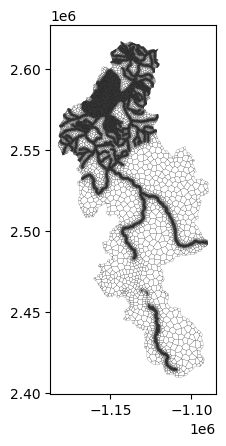

In [67]:
prmsgrid.boundary.plot(color='black',lw=0.1)